# muon → DE 仿真（Pipeline，精细模板）
使用 DESimConfig + Pipeline，自动解析并打印关键路径，给出 muon 文件示例名与运行步骤。

In [1]:

import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os

# 确保能 import 包（在仓库根运行时通常为 '.'）
sys.path.append('.')

from relics_de_sim.config import DESimConfig
from relics_de_sim.pipeline import Pipeline
import relics_de_sim as rds
importlib.reload(rds)
print('relics_de_sim package imported')


relics_de_sim package imported


In [2]:
import uproot
file_path = "/home/leiyang/TPC_DE_SIm-main/muon_track/merged_1_20_muon_lead_5cm_PE_30cm.root"
file = uproot.open(file_path)
file.keys()
tree = file['mcTree;1']
tree.keys()

['runId',
 'eventId',
 'seed',
 'nHits',
 'trackId',
 'parentId',
 'type',
 'parentType',
 'creatorProcess',
 'depositionProcess',
 'volume',
 'totalEnergy',
 'xd',
 'yd',
 'zd',
 'td',
 'energy',
 'nPrimaries',
 'primaryType',
 'primaryId',
 'primaryEnergy',
 'primaryPx',
 'primaryPy',
 'primaryPz',
 'primaryX',
 'primaryY',
 'primaryZ']

In [3]:
muon_track_example = np.load("/home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.2.npy")


In [4]:
muon_track_example.dtype.names

('eventId', 'type', 'energy', 'xd', 'yd', 'zd', 'td')

In [5]:
np.unique(muon_track_example['eventId'])

array([   0,    1,    2, ..., 1580, 1581, 1582], dtype=int32)

In [6]:
# 1) 加载并展示配置（使用仓内的 sim_config/Muon_sim.yaml）
cfg_rel = Path('../configs/muon_only.yaml')
if not cfg_rel.exists():
    raise FileNotFoundError(f'未找到配置文件: {cfg_rel.resolve()}')
cfg = DESimConfig.from_yaml(cfg_rel)
print('Loaded YAML source:', cfg.source_yaml)
print('Resolved paths:')
print(' muon_track_dir:', cfg.paths.muon_track_dir)
print(' lce_value:', cfg.paths.lce_value)
print(' position_reconstruction_model:', cfg.paths.position_reconstruction_model)
print('Simulation params: dead_time_s=', cfg.simulation.dead_time_s, ', muon_rate_hz=', cfg.simulation.muon_rate_hz)


Loaded YAML source: /home/leiyang/TPC_DE_SIm-main/configs/muon_only.yaml
Resolved paths:
 muon_track_dir: /home/leiyang/TPC_DE_SIm-main/muon_track
 lce_value: /home/leiyang/TPC_DE_SIm-main/LCE_info/LCE_value.npy
 position_reconstruction_model: /home/leiyang/TPC_DE_SIm-main/models/CnnRelics.ckpt
Simulation params: dead_time_s= 0.002 , muon_rate_hz= 3


In [7]:
# 2) 查找 muon track 文件示例（显示前若干个匹配名）
muon_dir = Path(cfg.paths.muon_track_dir)
if not muon_dir.exists():
    print('muon_track 目录不存在:', muon_dir)
    print('请检查 cfg.paths.muon_track_dir 或把 muon 文件放到该目录下')
else:
    matches = sorted(muon_dir.rglob('muon_track.*.npy'))
    if not matches:
        matches = sorted(muon_dir.rglob('*.npy'))
    print('找到 muon 文件数量:', len(matches))
    for p in matches[:10]:
        print(' ', p)


找到 muon 文件数量: 3
  /home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.0.npy
  /home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.1.npy
  /home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.2.npy


In [8]:
# 3) 构造 Pipeline 并按阶段运行（示例：只载入前 N 个 muon 文件）
pipe = Pipeline(cfg)
print('Pipeline created. device=', pipe.device)

if muon_dir.exists():
    matches = sorted(muon_dir.rglob('muon_track.*.npy')) or sorted(muon_dir.rglob('*.npy'))
    files = [str(p) for p in matches[:3]]
    if not files:
        print('没有找到 muon 文件，跳过 load_muon_tracks。')
    else:
        print('加载 muon 文件示例:', files)
        try:
            pipe.load_muon_tracks(files)
            print('Loaded muons: merged shape =', None if pipe.merged_muon is None else pipe.merged_muon.shape)
            print('dense muon shape =', None if pipe.dense_muon is None else pipe.dense_muon.shape)
        except Exception as e:
            print('load_muon_tracks 失败：', e)
else:
    print('请把 muon 文件放到', cfg.paths.muon_track_dir)


Pipeline created. device= auto
加载 muon 文件示例: ['/home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.0.npy', '/home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.1.npy', '/home/leiyang/TPC_DE_SIm-main/muon_track/muon_track.2.npy']


Reading muon files: 100%|██████████| 3/3 [00:00<00:00, 120.24it/s]


Loaded muons: merged shape = (172459,)
dense muon shape = (998400,)


In [9]:
# 4) 生成延迟电子、模拟 pattern、位置重建与评分（有条件执行）
if pipe.dense_muon is None:
    print('未生成 dense_muon —— 请先运行上一步')
else:
    print('simulate_delayed_electrons() ...')
    pipe.simulate_delayed_electrons()
    print('simulate_pile_up_patterns() ...')
    pipe.simulate_pile_up_patterns()
    print('recon_position_de() ...')
    try:
        pipe.recon_position_de()
    except Exception as e:
        print('位置重建失败（可能缺少模型或 PyTorch），错误：', e)
    print('score() ...')
    try:
        pipe.score()
    except Exception as e:
        print('评分失败：', e)
    # 概览每个 pile-up multiplicity 的 kept 事件数
    for order, res in zip(pipe.pile_up_orders, pipe.pile_up_results):
        print(f'order={order} kept={len(res.pe_by_area)}')


simulate_delayed_electrons() ...
simulate_pile_up_patterns() ...
recon_position_de() ...
Using device: cuda


/home/leiyang/TPC_DE_SIm-main/relics_de_sim/recon.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = self._torch.load(checkpoint_path, map_location=self.device)


model loaded from epoch /home/leiyang/TPC_DE_SIm-main/models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 169584/169584 [00:00<00:00, 584167.36it/s]


total samples:  169584 , using a 512 batch for data loader


...

total samples:  2392 , using a 512 batch for data loader


100%|██████████| 5/5 [00:00<00:00, 68.11it/s]


score() ...


space-time correlation: 100%|██████████| 1/1 [00:00<00:00,  2.57it/s]

order=2 kept=169584
order=3 kept=91205
order=4 kept=37721
order=5 kept=15101
order=6 kept=6044
order=7 kept=2392


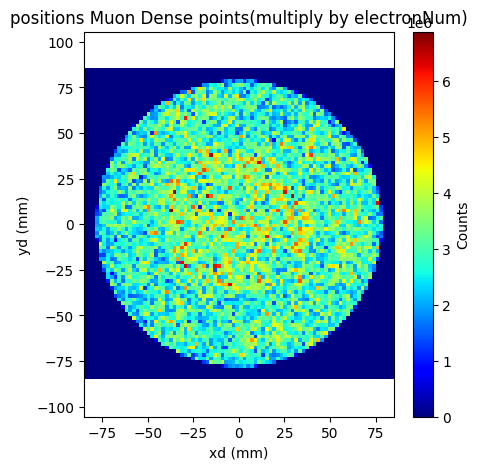

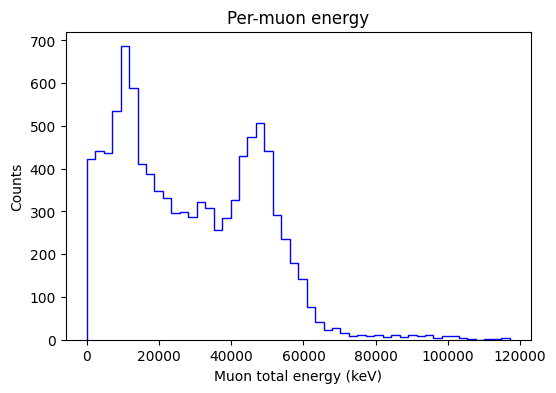

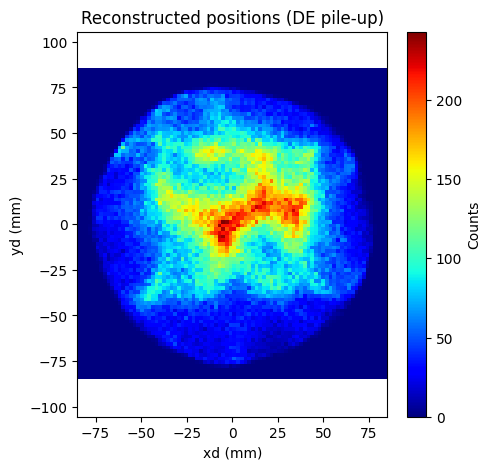

In [10]:
# 5) 可视化示例：每 muon 总能量直方图 + 如果有重建位置，绘制重建点
if pipe.merged_muon is not None:
    merged = pipe.merged_muon
    xd = merged['xd']
    yd = merged['yd']
    e_num = merged['electronNum']
    plt.figure(figsize=(5,5))
    xbins = np.linspace(-85,85,85)
    H, xedges, yedges = np.histogram2d(xd, yd, bins=(xbins, xbins), weights=e_num)
    plt.imshow(H.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
            aspect='auto', cmap='jet')
    plt.colorbar(label='Counts')
    plt.xlabel('xd (mm)')
    plt.ylabel('yd (mm)')
    plt.title('positions Muon Dense points(multiply by electronNum)')
    plt.axis('equal')
    plt.show()

if pipe.merged_muon is not None:
    merged = pipe.merged_muon
    event_ids = np.unique(merged['eventId'])
    energies = [np.sum(merged[merged['eventId'] == eid]['energy']) for eid in event_ids]
    plt.figure(figsize=(6,4))
    plt.hist(energies, bins=50, histtype='step', color='blue')
    plt.xlabel('Muon total energy (keV)')
    plt.ylabel('Counts')
    plt.title('Per-muon energy')
    plt.show()

if pipe.pile_up_pos_recon and any(len(a)>0 for a in pipe.pile_up_pos_recon):
    pos = np.vstack([a for a in pipe.pile_up_pos_recon if len(a)>0])
    plt.figure(figsize=(5,5))
    # 如果需要更多控制，也可以这样写
    xbins = np.linspace(-85,85,85)
    H, xedges, yedges = np.histogram2d(pos[:,0], pos[:,1], bins=(xbins, xbins))
    plt.imshow(H.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
            aspect='auto', cmap='jet')
    plt.colorbar(label='Counts')
    plt.xlabel('xd (mm)')
    plt.ylabel('yd (mm)')
    plt.title('Reconstructed positions (DE pile-up)')
    plt.axis('equal')
    plt.show()
else:
    print('无重建位置可绘制（可能没有运行 recon 或无事件）。')


In [11]:
len(np.concatenate(pipe.pile_up_pos_recon))

322047

In [12]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = pipe.pmt_top,title = "",savefig = False):
    artists = list()
    cmap = mpl.cm.viridis
    # 定义灰度色图
    # cmap = cm.get_cmap("viridis")
    # norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    # 修改1：添加有效性检查
    phe_pmt = np.asarray(phe_pmt)
    phe_pmt = np.nan_to_num(phe_pmt, nan=0.0)
    
    # 修改2：安全设置 norm
    max_val = phe_pmt.max()
    if max_val <= 1:
        # 如果最大值 <= 1，使用线性归一化
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, max_val))
    else:
        try:
            norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
        except ValueError:
            norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(28):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        if phe_pmt[pmt_id] < 0.1:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons[0]/10, pos_recons[0]/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    # angle = np.arange(13)*np.pi/6
    # outer_r = 14/np.cos(np.pi/12)
    # grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend()
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.legend()
    plt.show()
    return 0

In [13]:
pipe.delayed_electron

array([(   0, 72.32887202, 15.86389755, 3.06206336e+00, 3.06409688e+00),
       (   0, 74.89490046, 16.44048992, 3.06206336e+00, 3.06410753e+00),
       (   0, 71.84774169, 15.75578648, 3.06206336e+00, 3.06415202e+00),
       ...,
       (9983,  4.09706306, 35.95442195, 3.32786837e+03, 3.32945724e+03),
       (9983,  4.09706306, 35.95442195, 3.32786837e+03, 3.32962786e+03),
       (9983,  4.09706306, 35.95442195, 3.32786837e+03, 3.32984461e+03)],
      dtype=[('eventId', '<i4'), ('xd', '<f8'), ('yd', '<f8'), ('muon_time', '<f8'), ('e_time', '<f8')])

In [14]:
pipe.pile_up_results[3].pe_info

array([(    0, 0.90750437,  0,    4.43652229, 0),
       (    0, 0.22078231,  0,    4.43652229, 0),
       (    0, 0.71470417,  0,    4.43652229, 0), ...,
       (15100, 0.97391123, 55, 3247.26495846, 0),
       (15100, 0.23320137, 55, 3247.26495846, 0),
       (15100, 0.62830736, 55, 3247.26495846, 0)],
      dtype=[('event_id', '<u8'), ('area', '<f8'), ('channel', '<u2'), ('e_time', '<f8'), ('e_id', '<u4')])

In [15]:
pipe.pile_up_indices[2][0]

array([682, 683, 684, 685])

In [16]:
len(pipe.pile_up_results[0].light_pattern[0])

56

In [17]:
pipe.pile_up_indices[0][0]

array([2, 3])

In [18]:
pipe.delayed_electron['eventId']

array([   0,    0,    0, ..., 9983, 9983, 9983], dtype=int32)

/tmp/ipykernel_1589898/634096253.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


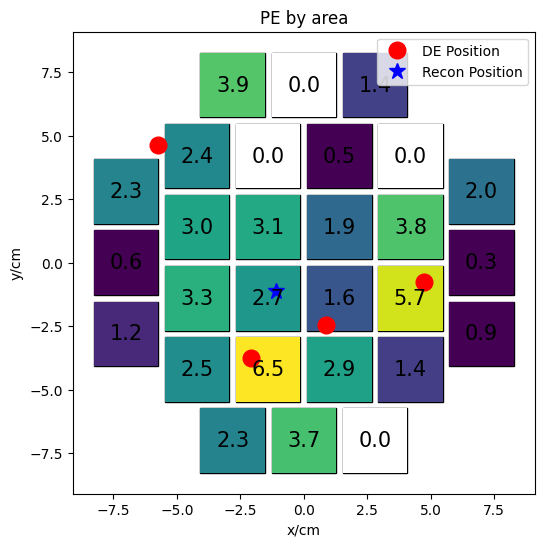

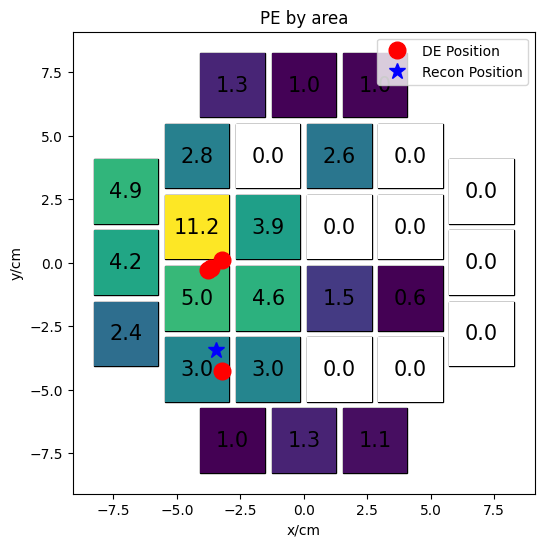

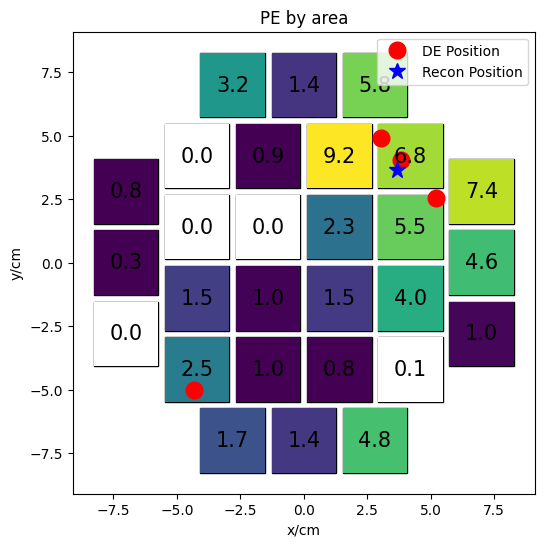

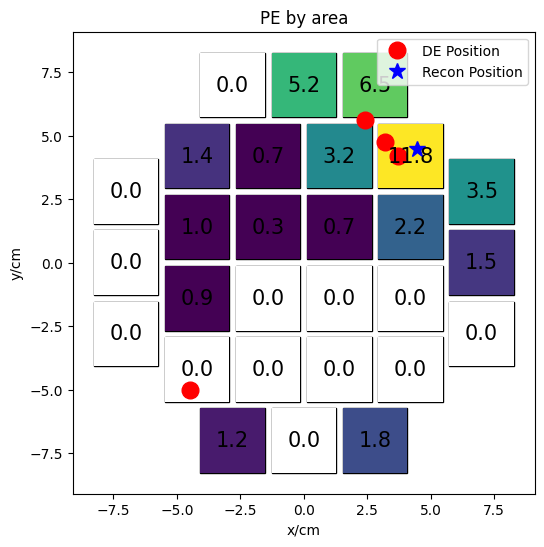

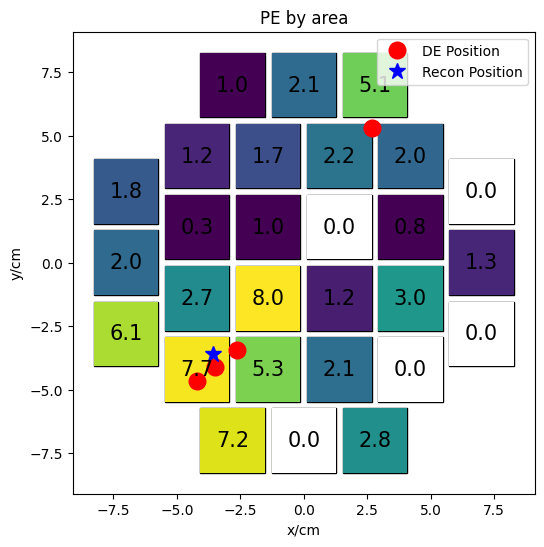

In [19]:
e_num = 4
mask = np.ptp(pipe.pile_up_events[e_num-2]['eventId'], axis=1) != 0 
np.sum(mask)
valid_indices = np.where(mask)[0]

for i in range(min(5, len(valid_indices))):
    idx = valid_indices[i]
# pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(pipe.pile_up_results[e_num-2].pe_by_area[idx], electron=pipe.pile_up_events[e_num-2][idx], pos_recons = pipe.pile_up_pos_recon[e_num-2][idx], pmt_info = pipe.pmt_top,title = "PE by area")

In [20]:
pattern = np.concatenate(pipe.pile_up_pattern_coef)
st_cor = np.concatenate(pipe.pile_up_st_cor)

In [21]:
len(pattern)

322047

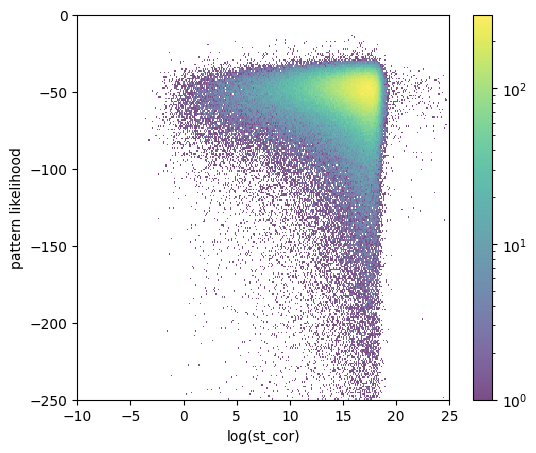

In [22]:
from matplotlib.colors import LogNorm

x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [23]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-main/data/cevns_sim_20_3e.npz


In [24]:
from pathlib import Path
muon_files = [Path(cfg.paths.muon_track_dir) / f'muon_track.{i}.npy' for i in range(3)]
pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
pipe_cevns.load_muon_tracks(muon_files)
print(f'time range: {pipe_cevns.time_range_s:.1f} s')

Reading muon files: 100%|██████████| 3/3 [00:00<00:00, 392.80it/s]


time range: 3328.0 s


In [25]:
try:
    pipe_cevns.simulate_cevns()
    for arr in pipe_cevns.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

Using device: cuda
model loaded from epoch /home/leiyang/TPC_DE_SIm-main/models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 1/1 [00:00<00:00, 18558.87it/s]


total samples:  1 , using a 512 batch for data loader


100%|██████████| 1/1 [00:00<00:00, 47.62it/s]

Using device: cuda


...

model loaded from epoch /home/leiyang/TPC_DE_SIm-main/models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 405/405 [00:00<00:00, 360733.30it/s]


total samples:  405 , using a 512 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 25.31it/s]

n_e=2: 1 events
n_e=3: 237124 events
n_e=4: 125305 events
n_e=5: 59529 events
n_e=6: 23521 events
n_e=7: 8290 events
n_e=8: 3059 events
n_e=9: 1086 events
n_e=10: 405 events


In [26]:
arr = np.concatenate(pipe_cevns.cevns_points)

In [27]:
from relics_de_sim.cuts import (
    PatternSTCut,
    fit_pattern_st_cut,
    pattern_likelihood,
)

cevns_st_cor = arr['st_cor']
cevns_pattern = pattern_likelihood(arr['pe_by_area'], arr['recons_light_pattern'], n_top=28)

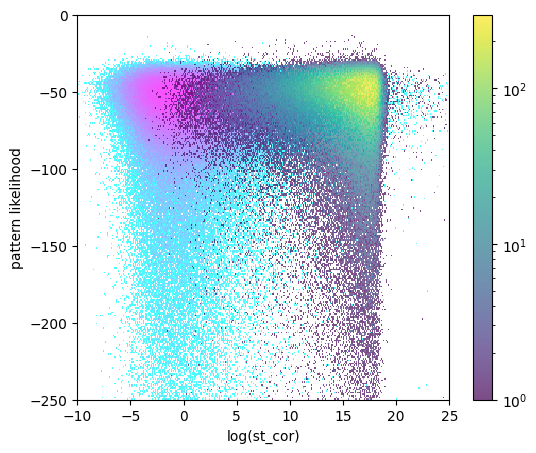

In [28]:
x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern, bins = (x_bins, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [29]:
cevns_area = np.sum(arr['pe_by_area'],axis=1)
cevns_area

array([118.26056259, 116.08367133, 108.74647703, ..., 201.22772401,
       153.56811084, 122.0390645 ])

In [30]:
len(pipe.pile_up_results)

6

In [31]:
DE_pe_by_area = []
for i in range(len(pipe.pile_up_results)):
    DE_pe_by_area.append(pipe.pile_up_results[i].pe_by_area)

In [32]:
DE_pe_by_area = np.concatenate(DE_pe_by_area)

In [33]:
DE_area = np.sum(DE_pe_by_area,axis=1)
DE_area

array([ 95.66899663,  91.54900449, 106.14241991, ..., 298.29450888,
       251.50500772, 212.16061495])

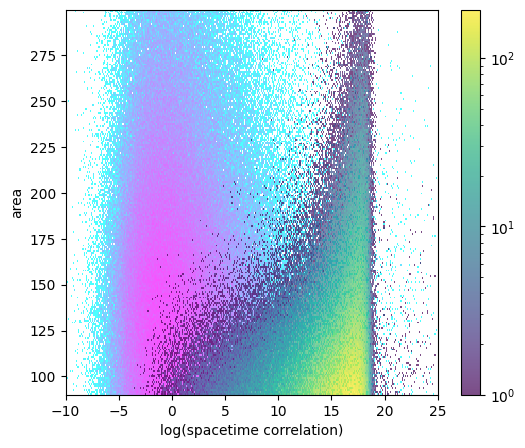

In [34]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

In [35]:
arr.dtype

dtype([('cevnsID', '<i4'), ('pos_original', [('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')]), ('t', '<f8'), ('num_e', '<f8'), ('light_pattern', '<f8', (56,)), ('pe_pattern', '<u2', (56,)), ('area_pattern', '<f8', (56,)), ('pe_by_area', '<f8', (56,)), ('pos_recon', [('xd', '<f8'), ('yd', '<f8')]), ('recons_light_pattern', '<f8', (56,)), ('st_cor', '<f8')])

In [36]:
cevns_pe_by_area = arr['pe_by_area']
cevns_pe_by_area.shape

(458320, 56)

/tmp/ipykernel_1589898/634096253.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


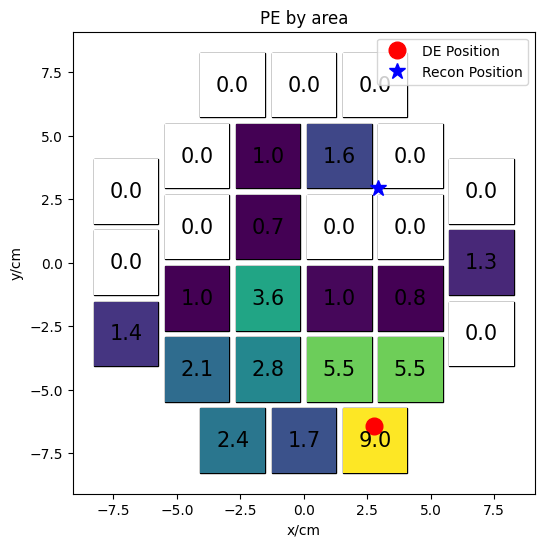

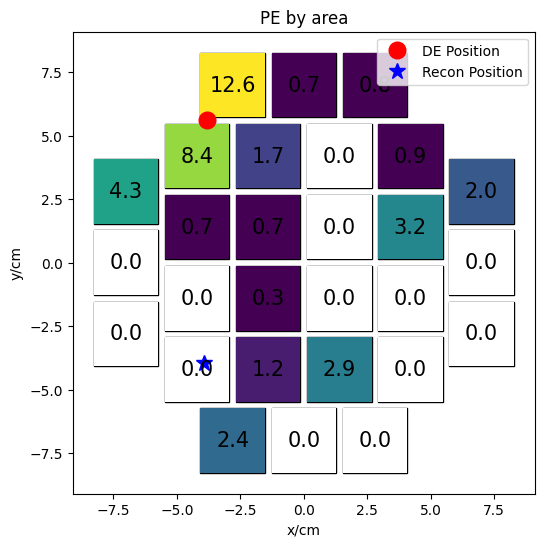

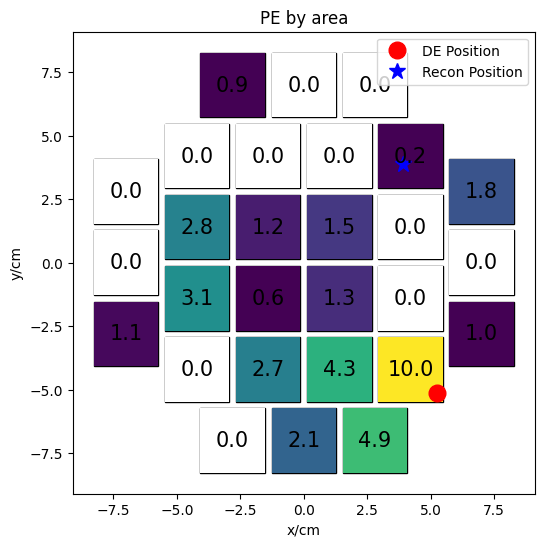

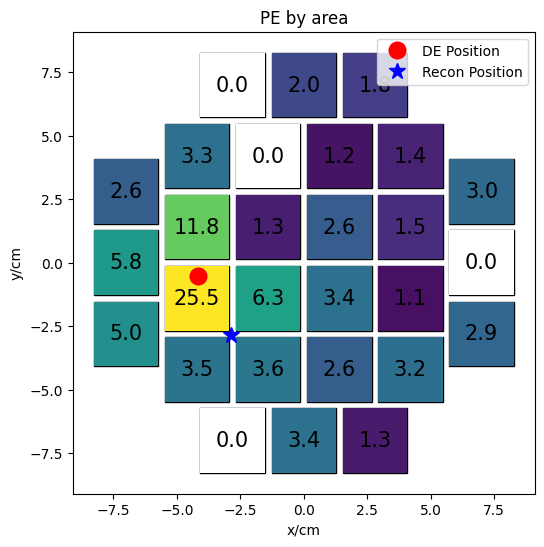

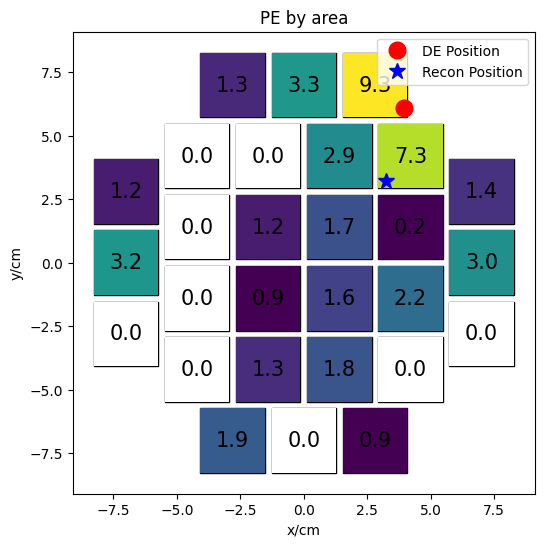

In [37]:
for i in range(5):
    
# pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(cevns_pe_by_area[i], electron=arr['pos_original'][i], pos_recons = arr['pos_recon'][i], pmt_info = pipe.pmt_top,title = "PE by area")

In [38]:
from tqdm import tqdm

def position_variance(pe_by_area, pmt_info = pipe.pmt_top, n_top=28):

    # 计算每个事件的加权平均位置
    weights = pe_by_area / np.sum(pe_by_area, axis=1, keepdims=True)
    weights_top = weights[:, :n_top]

    pmts = np.array(pmt_info[:n_top])
    
    pos_variance = []
    for item in tqdm(weights_top):
        x_virance = np.std(item*pmts['x'])
        y_virance = np.std(item*pmts['y'])

        pos_variance.append(x_virance**2+y_virance**2)
    return pos_variance

In [39]:
cevns_pos_virance = position_variance(cevns_pe_by_area)
DE_pos_virance = position_variance(DE_pe_by_area)

100%|██████████| 322047/322047 [00:11<00:00, 28596.75it/s]


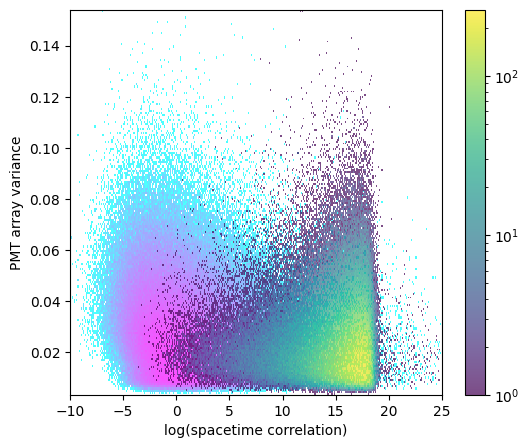

In [40]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_pos_virance, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_pos_virance, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('PMT array variance')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

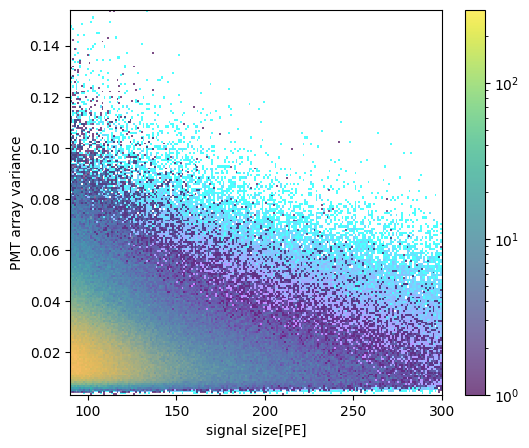

In [41]:

y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(cevns_area, cevns_pos_virance, bins = (200,200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(DE_area, DE_pos_virance, bins = (200,200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('signal size[PE]'); ax.set_ylabel('PMT array variance')
plt.colorbar(h[3], ax=ax)
plt.xlim(90,300)
# plt.ylim(-250,0)
plt.show()

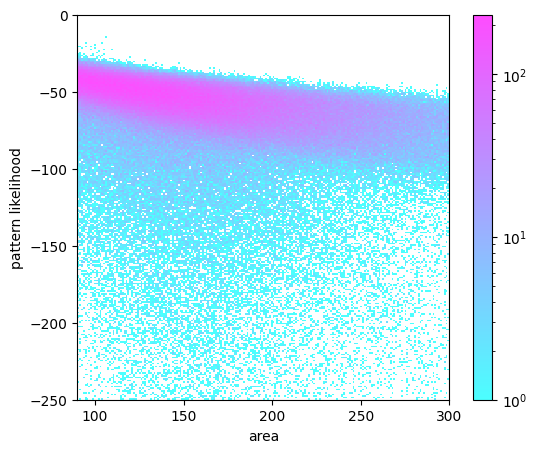

In [42]:
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(cevns_area, cevns_pattern, bins = (200, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(DE_area, pattern, bins = (200, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('area'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(90,300)
plt.ylim(-250,0)
plt.show()

In [43]:
def calculate_score(st_cor, area, k_area):
    return  k_area * area - np.log(st_cor)

In [44]:
from tqdm import tqdm

exposure = []

k_area_list = np.arange(-0.1,0.4,0.005)
k_list = []
exposure_k = []
for k in tqdm(k_area_list):
    score_cevns = calculate_score(cevns_st_cor, cevns_area, k_area = k)
    score_DE = calculate_score(st_cor, DE_area, k_area = k)
    valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
    valid_score_DE = score_DE[~np.isnan(score_DE)]   
    x = np.percentile(valid_score_DE, 100-0.01)
    exposure_k.append(len(valid_score_cevns[valid_score_cevns>x])/len(valid_score_cevns))
    k_list.append([k,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████| 100/100 [00:01<00:00, 81.69it/s]


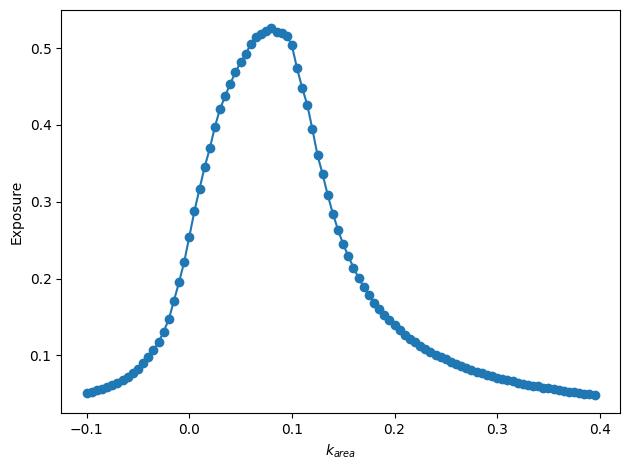

In [45]:
plt.figure()

plt.plot(k_area_list, exposure_k, marker='o')
plt.xlabel(r"$k_{area}$")
plt.ylabel("Exposure")
plt.tight_layout()

plt.show()

In [46]:
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_area, b = k_list[index_of_max]
b = -b

[0.08000000000000015, 11.596959661272772] 0.5256349275615291


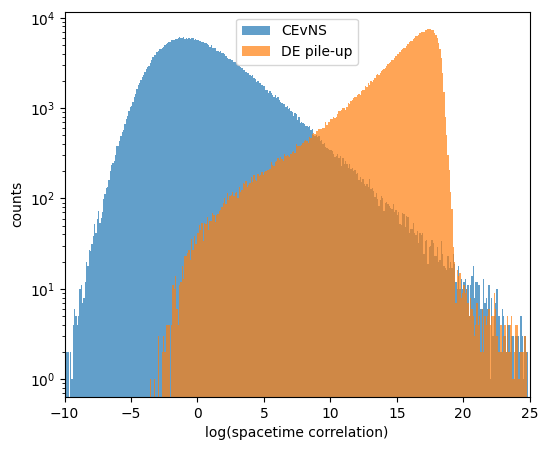

In [47]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist(np.log(cevns_st_cor), bins = x_bins, alpha = 0.7, label = 'CEvNS')
h = ax.hist(np.log(st_cor), bins = x_bins, alpha = 0.7, label = 'DE pile-up')
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('counts')

plt.xlim(-10,25)
plt.yscale('log')
plt.legend()
plt.show()

269


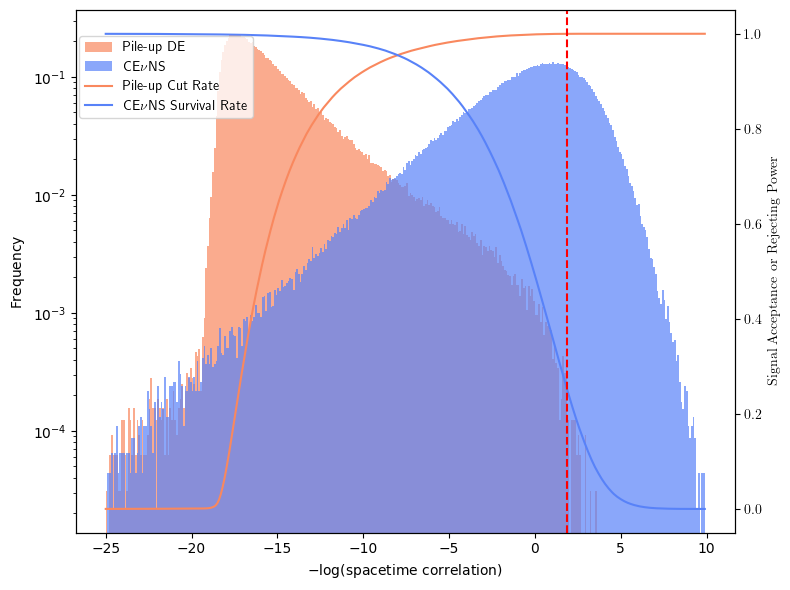

In [48]:
thresholds = np.arange(-25, 10, 0.1)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(-np.log(st_cor) < threshold) / len(np.log(st_cor))
    right_cevns_ratio = np.sum(-np.log(cevns_st_cor) > threshold) / len(np.log(cevns_st_cor))
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)


left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.0001):
    index = np.argmax(left_DE_ratios > 1-0.0001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-25, 10, 0.1)

ax1.hist(-np.log(st_cor), bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(-np.log(cevns_st_cor), bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{-log(spacetime\ correlation)}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图


In [49]:
score_DE = -np.log(st_cor) + k_area * DE_area - b
score_CEvNS = -np.log(cevns_st_cor) + k_area * cevns_area - b
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]
score_DE = score_DE[~np.isnan(score_DE)]

In [50]:
thresholds = np.arange(-25, 50, 0.2)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_CEvNS > threshold) / len(score_CEvNS)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

In [51]:
left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.0001):
    index = np.argmax(left_DE_ratios > 1-0.0001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

241


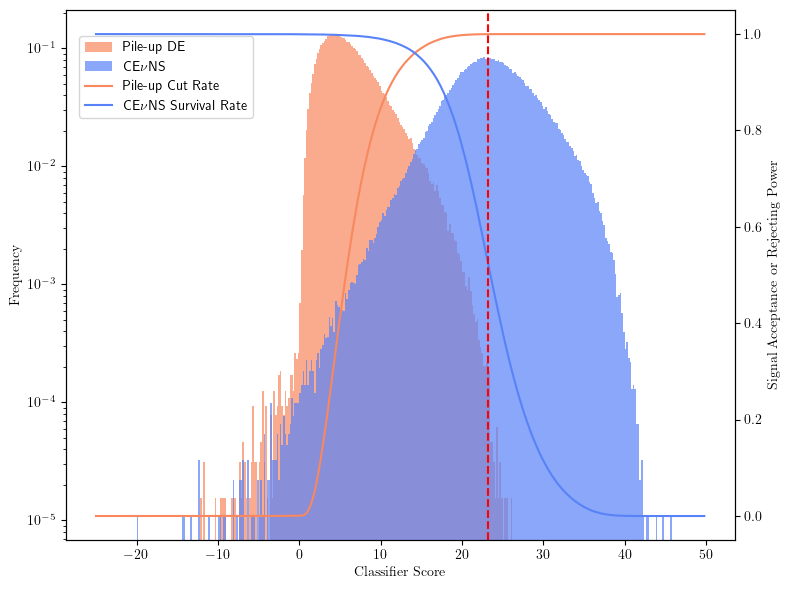

In [52]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-25, 50, 0.2)

ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图
